# Bounded Confidence Opinion Dynamics Model

This notebook demonstrates the bounded confidence model featuring two versions.
Both versions interact at random with either:
- All Agents
- Neighbouring agents in a grid

## Model Description

In this model, agents have continuous opinions on [0, 1] and interact in random pairs. When two agents meet:
- If their opinion difference is below threshold $d$, they adjust their opinions
- Opinion adjustment follows: $x = x + \mu(x' - x)$ and $x' = x' + \mu(x - x')$
- Where $\mu$ is the convergence parameter, $d$ is the threshold and $x$ and $x'$ are the opinions of both agents.

This model demonstrates how opinion polarization emerges from simple local interaction rules.

In [ ]:
# Install required packages if not already done
%pip install mesa seaborn numpy pandas matplotlib networkx

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mesa import Model, Agent, batch_run
from mesa.discrete_space import CellAgent, OrthogonalVonNeumannGrid
from mesa.datacollection import DataCollector

# Set style for better visualizations
sns.set_theme()

## Part 1: Choose from all Agents (Homogeneous Mixing)

In this version, agents can interact with any other agent in the population, simulating complete mixing.

In [3]:
def get_opinion_groups(model):
    """Count the number of distinct opinion groups based on threshold."""
    epsilon = 0.05 #How different can opinions be to not be considered part of the same group?
    agents_opinions = [agent.opinion for agent in model.agents] #get a list of agents opinions
    agents_opinions.sort() #Sort the list
    #Get a list that always contains the differences between 2 consecutive opinions.
    #Compare them all against epsilon; return True/1 for if the opinions diverge enough to belong to different groups; False/0 otherwise.
    #Count the amount of group switches (sum the comparisons up); add 1 to get the Number of total Groups
    return sum(np.diff(agents_opinions) > epsilon) + 1


In [4]:
class BoundedConfidenceAgent(Agent):
    """An agent that holds an opinion and adjusts it through bounded confidence interactions."""

    def __init__(self, model: Model, opinion: float):
        """
        Create a new bounded confidence agent.

        Args:
            model: The model instance
            opinion: Initial opinion value (0 to 1)
        """
        super().__init__(model)
        self.opinion = opinion

    def step(self):
        """Execute one step: interact with a random agent."""
        # Select a random agent to interact with
        other_agent = self.random.choice(self.model.agents)

        # Calculate opinion difference
        opinion_distance = abs(self.opinion - other_agent.opinion)

        # Adjust opinions if within threshold
        if opinion_distance < self.model.threshold:
            # Store original opinion to avoid using updated value
            original_other_opinion = other_agent.opinion

            # Update both agents' opinions
            other_agent.opinion += self.model.convergence * (self.opinion - other_agent.opinion)
            self.opinion += self.model.convergence * (original_other_opinion - self.opinion)

In [5]:
class BoundedConfidenceModel(Model):
    """Model with homogeneous mixing: all agents can interact with all others."""

    def __init__(self, n_agents: int, threshold: float, convergence: float, seed: int = None):
        """
        Initialize the bounded confidence model.

        Args:
            n_agents: Number of agents
            threshold: Opinion difference threshold (0 to 1)
            convergence: Convergence parameter (0 to 0.5)
            seed: Random seed for reproducibility
        """
        super().__init__(rng=seed)
        self.num_agents = n_agents
        self.threshold = threshold
        self.convergence = convergence

        # Create agents with random initial opinions from uniform distribution [0, 1]
        random_opinions = [self.random.random() for _ in range(self.num_agents)]
        BoundedConfidenceAgent.create_agents(self, self.num_agents, random_opinions)

        # Set up data collection
        self.datacollector = DataCollector(
            model_reporters={"Opinion_groups": get_opinion_groups},
            agent_reporters={"Opinion": "opinion"},
        )
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one step."""
        # Activate all agents in random order
        self.agents.shuffle_do("step")
        # Collect data
        self.datacollector.collect(self)

### Running the Analytical Model

In [6]:
RANDOM_SEED = 42
ROUNDS = 100
AGENTS = 100

# Create and run model with high threshold (convergence expected)
model_high_threshold = BoundedConfidenceModel(n_agents=AGENTS, threshold=0.5, convergence=0.5, seed=RANDOM_SEED)
model_high_threshold.run_for(ROUNDS)

print(f"Number of opinion groups: {get_opinion_groups(model_high_threshold)}")

# Create and run model with low threshold (polarization expected)
model_low_threshold = BoundedConfidenceModel(n_agents=AGENTS, threshold=0.2, convergence=0.5, seed=RANDOM_SEED)
model_low_threshold.run_for(ROUNDS)

print(f"Number of opinion groups: {get_opinion_groups(model_low_threshold)}")

Number of opinion groups: 1
Number of opinion groups: 2


In [7]:
# Plots multiple Opinion Dynamic Situations in one Figure
# Yes, this function is pretty complex! Don't be disappointed if you don't understand it all, you can also write functions simpler!
def visualize_opinion_dynamics_multiple(agent_data_list, titles, visualization_steps=[50]):
    """Visualize the opinion dynamics of multiple models in subplots."""
    # Create a figure that contains multiple subplots (nrows rows, 1 column)
    fig, axes = plt.subplots(nrows=len(agent_data_list), ncols=1, figsize=(10, 4 * len(agent_data_list)))

    # With axes[i] you normally access the subplots. If there is only one subplot, you would normally access it simply with axes. Make this consistent in case only one plot needs to be plottet.
    if len(agent_data_list) == 1:
        axes = [axes]  # Make it iterable for single model case

    # Create the individual sub-plots one by one
    # zip takes multiple lists of the same length and re-organizes them; always taking the i'th item from each input list. Basically [(agent_data_list[0], titles[0], visualization_steps[0]), (agent_data_list[1], ...), ...]
    # Enumerate takes each element one by one and adds a index to them.
    # That is then feed to the individual variables i (from enumerate), agent_data (agent_data_list[i]), title (titles[i]), steps (visualization_steps[i])
    for i, (agent_data, title, steps) in enumerate(zip(agent_data_list, titles, visualization_steps)):
        ax = axes[i]
        agent_data = agent_data.reset_index() #remove the anoying index (AgentID becomes its own column)

        # Go through each agent and plot the line
        for agent_id in agent_data['AgentID'].unique():
            agent_opinions = agent_data[agent_data['AgentID'] == agent_id]
            agent_shortened_opinions = agent_opinions[agent_opinions['Step'] <= steps] #Create artificial cutoff to maybe see starting behavior more clearly
            ax.plot(agent_shortened_opinions['Step'], agent_shortened_opinions['Opinion'], alpha=0.5, linewidth=0.5) #X-Axis: Step-number; Y-Axis: Opinion

        ax.set_xlabel('Step')
        ax.set_ylabel('Opinion')
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

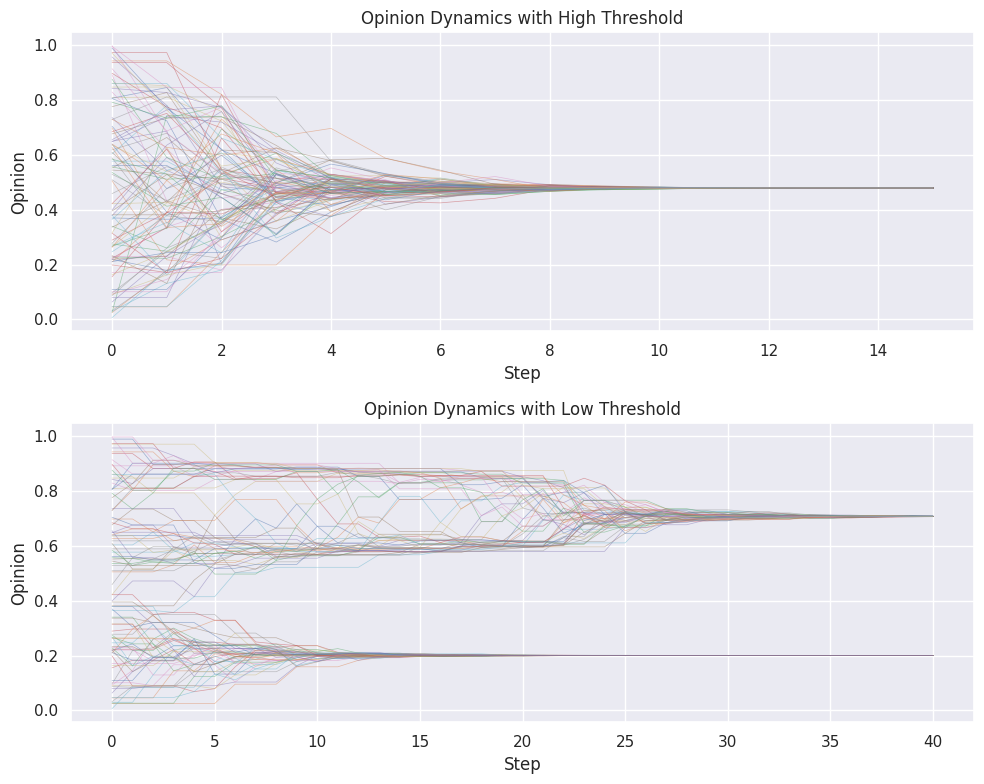

In [8]:
# Visualize both models together using the new function
data_list = [model_high_threshold.datacollector.get_agent_vars_dataframe(), model_low_threshold.datacollector.get_agent_vars_dataframe()]
titles = ["Opinion Dynamics with High Threshold", "Opinion Dynamics with Low Threshold"]
visualization_steps = [15, 40]
visualize_opinion_dynamics_multiple(data_list, titles, visualization_steps)

### Using batch_run for multiple configurations

In [9]:
# batch run with different thresholds
ROUNDS = 100

parameters = {
    "n_agents": [100,500], #All the different values we want to try out
    "convergence": 0.5,
    "threshold": [0.2, 0.3, 0.4, 0.5]  # Different thresholds to test
}

#For Windows number_processes=1 is important! Don't set it higher there!
#data_collection_period: After how many steps should the data be collected? -1 (the default): Only at the end
#rng: The random seed(s) that should be used for running the simulation
results = batch_run(BoundedConfidenceModel, parameters, max_steps=ROUNDS, number_processes=1, data_collection_period=1, rng=[42])

  0%|          | 0/8 [00:00<?, ?it/s]

In [10]:
# Sadly the datacollector of the batchrunner returns the data in a format which is difficult to work it. Therefore convert batch_run results to a DataFrame.
results_df = pd.DataFrame(results)
#get a preview of the results
display(results_df.head())
#Inspect the different combinations
display(results_df.drop(columns=["AgentID", "Step", 'Opinion']).drop_duplicates())

# Create a individual dataframe for each run and add them all to a list
run_dataframes = []
for run_id, group in results_df.groupby("RunId"):
    df = group.loc[:, ["Step", "AgentID", "Opinion", "threshold", "n_agents"]].reset_index(drop=True) #Only keep these columns and reset the Index (completely remove the old index)
    run_dataframes.append(df)

# Example: inspect the first run dataframe
print("Number of runs:", len(run_dataframes))
display(run_dataframes[0])

,RunId,iteration,Step,n_agents,convergence,threshold,seed,Opinion_groups,AgentID,Opinion
0,0,0,0.0,100,0.5,0.2,42,1,1,0.639427
1,0,0,0.0,100,0.5,0.2,42,1,2,0.025011
2,0,0,0.0,100,0.5,0.2,42,1,3,0.275029
3,0,0,0.0,100,0.5,0.2,42,1,4,0.223211
4,0,0,0.0,100,0.5,0.2,42,1,5,0.736471


,RunId,iteration,n_agents,convergence,threshold,seed,Opinion_groups
0,0,0,100,0.5,0.2,42,1
100,0,0,100,0.5,0.2,42,3
200,0,0,100,0.5,0.2,42,4
400,0,0,100,0.5,0.2,42,6
700,0,0,100,0.5,0.2,42,5
2000,0,0,100,0.5,0.2,42,2
10100,1,0,100,0.5,0.3,42,1
10300,1,0,100,0.5,0.3,42,3
10400,1,0,100,0.5,0.3,42,4
10600,1,0,100,0.5,0.3,42,2


Number of runs: 8


,Step,AgentID,Opinion,threshold,n_agents
0,0.0,1,0.639427,0.2,100
1,0.0,2,0.025011,0.2,100
2,0.0,3,0.275029,0.2,100
3,0.0,4,0.223211,0.2,100
4,0.0,5,0.736471,0.2,100
...,...,...,...,...,...
10095,100.0,96,0.707825,0.2,100
10096,100.0,97,0.707825,0.2,100
10097,100.0,98,0.707825,0.2,100
10098,100.0,99,0.707825,0.2,100


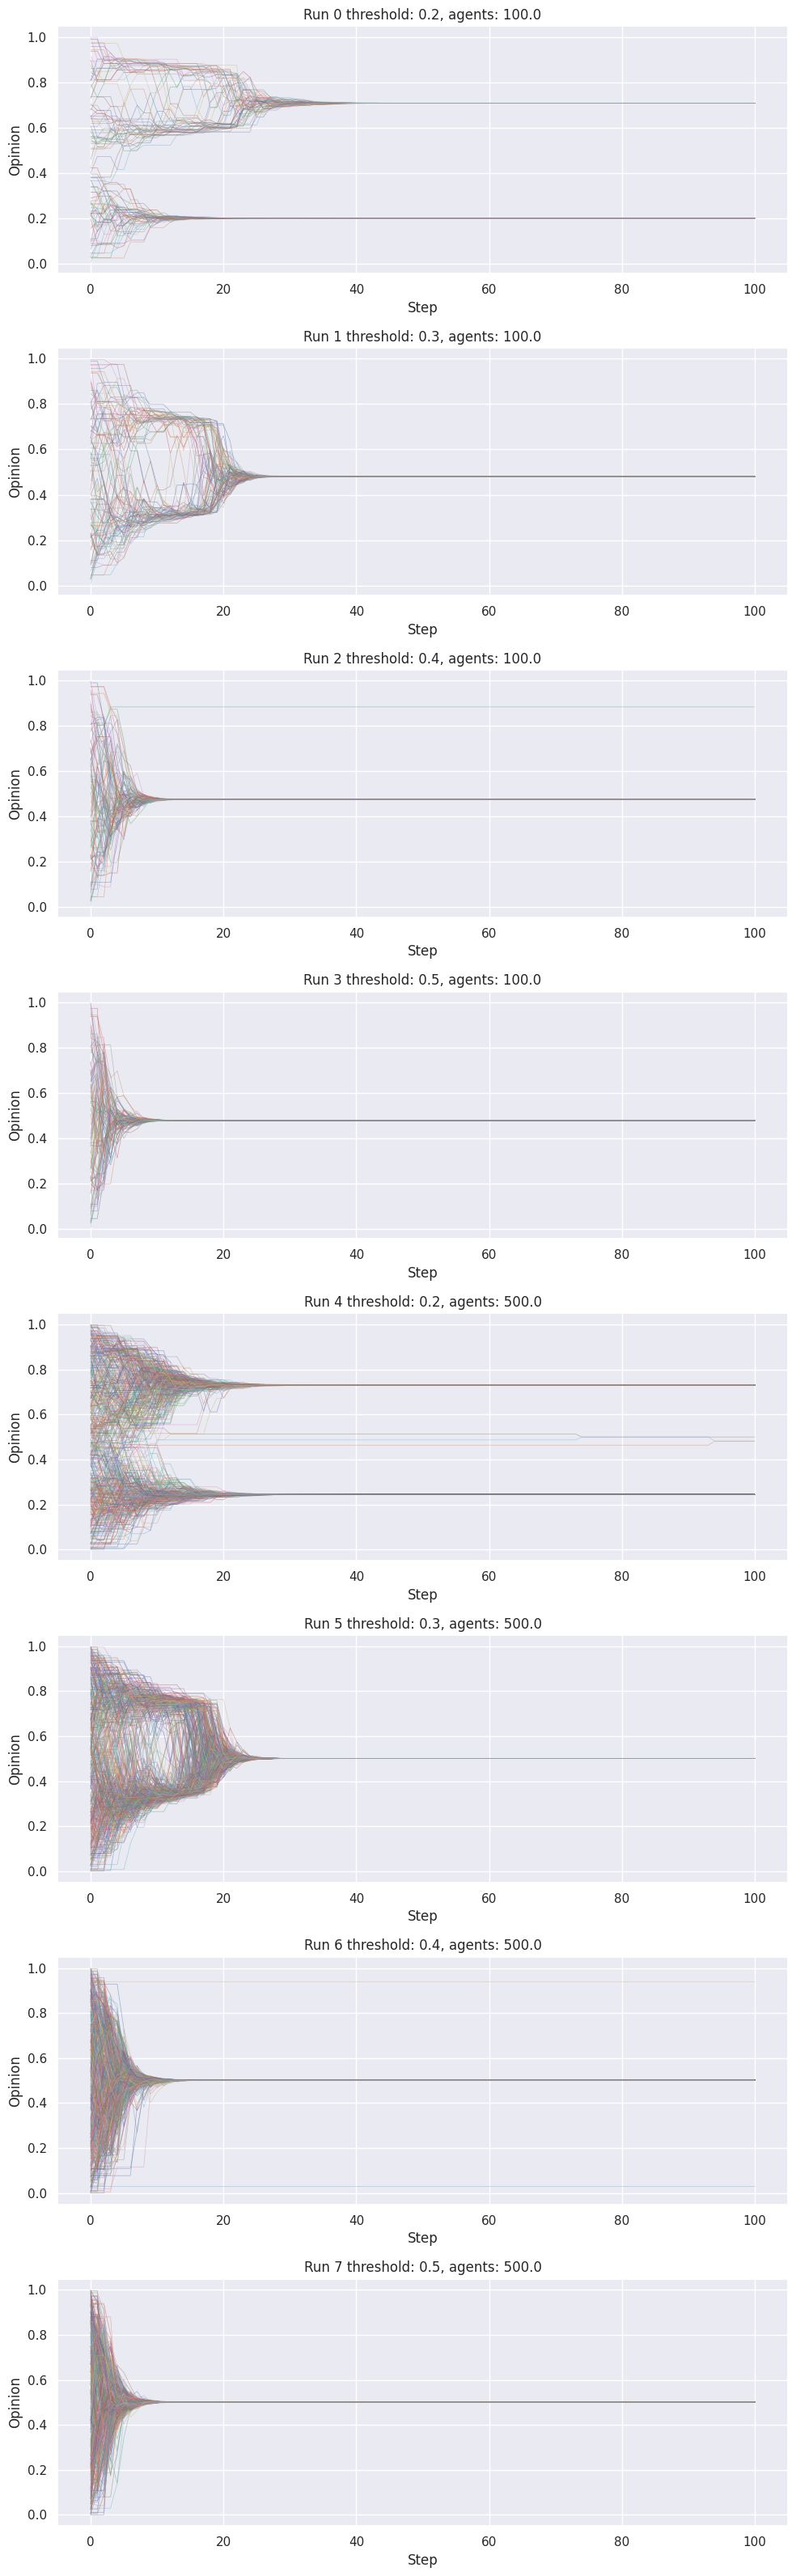

In [11]:
visualize_opinion_dynamics_multiple(run_dataframes,
                                    titles=[f"Run {i} threshold: {run_dataframes[i].iloc[0]['threshold']}, agents: {run_dataframes[i].iloc[0]['n_agents']}" for i in range(len(run_dataframes))],
                                    visualization_steps=[ROUNDS]*len(run_dataframes))

## Part 2 (Not shown in Tutorial): Grid-Based Model (Spatial Interactions)

In this version, agents are placed on a grid and can only interact with their grid neighbors.

In [12]:
#Same code as above
def get_opinion_groups(model):
    """Count the number of distinct opinion groups based on threshold."""
    epsilon = 0.05 #How different can opinions be to not be considered part of the same group?
    agents_opinions = [agent.opinion for agent in model.agents] #get a list of agents opinions
    agents_opinions.sort() #Sort the list
    #Get a list that always contains the differences between 2 consecutive opinions.
    #Compare them all against epsilon; return True/1 for if the opinions diverge enough to belong to different groups; False/0 otherwise.
    #Count the amount of group switches (sum the comparisons up); add 1 to get the Number of total Groups
    return sum(np.diff(agents_opinions) > epsilon) + 1
# Plots multiple Opinion Dynamic Situations in one Figure
# Yes, this function is pretty complex! Don't be disappointed if you don't understand it all, you can also write functions simpler!
def visualize_opinion_dynamics_multiple(agent_data_list, titles, visualization_steps=[50]):
    """Visualize the opinion dynamics of multiple models in subplots."""
    # Create a figure that contains multiple subplots (nrows rows, 1 column)
    fig, axes = plt.subplots(nrows=len(agent_data_list), ncols=1, figsize=(10, 4 * len(agent_data_list)))

    # With axes[i] you normally access the subplots. If there is only one subplot, you would normally access it simply with axes. Make this consistent in case only one plot needs to be plottet.
    if len(agent_data_list) == 1:
        axes = [axes]  # Make it iterable for single model case

    # Create the individual sub-plots one by one
    # zip takes multiple lists of the same length and re-organizes them; always taking the i'th item from each input list. Basically [(agent_data_list[0], titles[0], visualization_steps[0]), (agent_data_list[1], ...), ...]
    # Enumerate takes each element one by one and adds a index to them.
    # That is then feed to the individual variables i (from enumerate), agent_data (agent_data_list[i]), title (titles[i]), steps (visualization_steps[i])
    for i, (agent_data, title, steps) in enumerate(zip(agent_data_list, titles, visualization_steps)):
        ax = axes[i]
        agent_data = agent_data.reset_index() #remove the anoying index (AgentID becomes its own column)

        # Go through each agent and plot the line
        for agent_id in agent_data['AgentID'].unique():
            agent_opinions = agent_data[agent_data['AgentID'] == agent_id]
            agent_shortened_opinions = agent_opinions[agent_opinions['Step'] <= steps] #Create artificial cutoff to maybe see starting behavior more clearly
            ax.plot(agent_shortened_opinions['Step'], agent_shortened_opinions['Opinion'], alpha=0.5, linewidth=0.5) #X-Axis: Step-number; Y-Axis: Opinion

        ax.set_xlabel('Step')
        ax.set_ylabel('Opinion')
        ax.set_title(title)

    plt.tight_layout()
    plt.show()


In [13]:
class BoundedConfidenceGridAgent(CellAgent):
    """An agent that lives on a grid and interacts with neighbors only."""

    def __init__(self, model: Model, cell, opinion: float):
        """
        Create a new grid-based bounded confidence agent.

        Args:
            model: The model instance
            cell: The grid cell this agent occupies
            opinion: The random opinion value of the agent
        """
        super().__init__(model)
        self.cell = cell
        self.opinion = opinion

    def step(self):
        """Interact with a random neighbor."""
        # Get list of neighbors (Specified in the Model later: von Neumann neighborhood: N, S, E, W)
        other_agent = self.cell.neighborhood.select_random_agent()

        if other_agent:
            # Calculate opinion difference
            opinion_distance = abs(self.opinion - other_agent.opinion)

            # Adjust opinions if within threshold
            if opinion_distance < self.model.threshold:
                original_other_opinion = other_agent.opinion

                other_agent.opinion += self.model.convergence * (self.opinion - other_agent.opinion)
                self.opinion += self.model.convergence * (original_other_opinion - self.opinion)

In [14]:
class BoundedConfidenceGridModel(Model):
    """Model with spatial structure: agents interact only with grid neighbors."""

    def __init__(self, width: int, height: int, threshold: float, convergence: float, seed: int = None, is_square = False):
        """
        Initialize the grid-based bounded confidence model.

        Args:
            width: Grid width
            height: Grid height
            threshold: Opinion difference threshold (0 to 1)
            convergence: Convergence parameter (0 to 0.5)
            seed: Random seed for reproducibility
            is_square: Determines if only weight is used for both sides
        """
        super().__init__(rng=seed)
        self.width = width
        if is_square:
            self.height = width
        else:
            self.height = height
        self.threshold = threshold
        self.convergence = convergence

        # Create grid (N, S, E, W)
        self.grid = OrthogonalVonNeumannGrid((self.width, self.height), random=self.random)

        # Create one agent per grid cell
        random_opinions = [self.random.random() for _ in range(self.width * self.height)]
        BoundedConfidenceGridAgent.create_agents(self, self.width * self.height, self.grid.all_cells.cells, random_opinions)

        # Set up data collection
        self.datacollector = DataCollector(
            model_reporters={"Opinion_groups": get_opinion_groups,
                             "Opinion_grid": self.get_grid_opinions},
            agent_reporters={"Opinion": "opinion"},
        )
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one step."""
        # Activate all agents in random order
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

    def get_grid_opinions(self):
        opinions_grid = np.zeros((self.width, self.height))
        for cell in self.grid.all_cells.cells:
            if cell.agents:
                opinions_grid[cell.coordinate] = cell.agents[0].opinion

        return opinions_grid

### Running the Grid-Based Model

In [15]:
# Create and run grid model
GRID_ROUNDS = 100
grid_model = BoundedConfidenceGridModel(width=20, height=20, threshold=0.3, convergence=0.5)
grid_model.run_for(GRID_ROUNDS)

print(f"Number of opinion groups: {get_opinion_groups(grid_model)}")

Number of opinion groups: 4


In [16]:
# model_data_list: A list of agent data
# rounds: How many rounds did the simulation run?
def visualize_opinion_grid(model_data_list: list[pd.DataFrame], rounds):
    fig, axes = plt.subplots(nrows=len(model_data_list), ncols=3, figsize=(14, 4 * len(model_data_list)))

    if len(model_data_list) == 1:
        axes = [axes]  # Make it iterable for single model case

    for i, model_data in enumerate(model_data_list):
        steps = [2, int(rounds/5), rounds] #We want to plot polarisation at the early beginning; after 20% of the rounds and at the end
        opinions_grids = [model_data.iloc[j-1] for j in steps]

        for col, step, opinions_grid in zip(range(len(steps)), steps, opinions_grids):
            ax = axes[i][col]
            im = ax.imshow(opinions_grid['Opinion_grid'], cmap='RdYlBu_r', vmin=0, vmax=1) #Plot the grd
            ax.set_title(f'Spatial Opinion Distribution at step {step}')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Opinion')
    plt.tight_layout()
    plt.show()

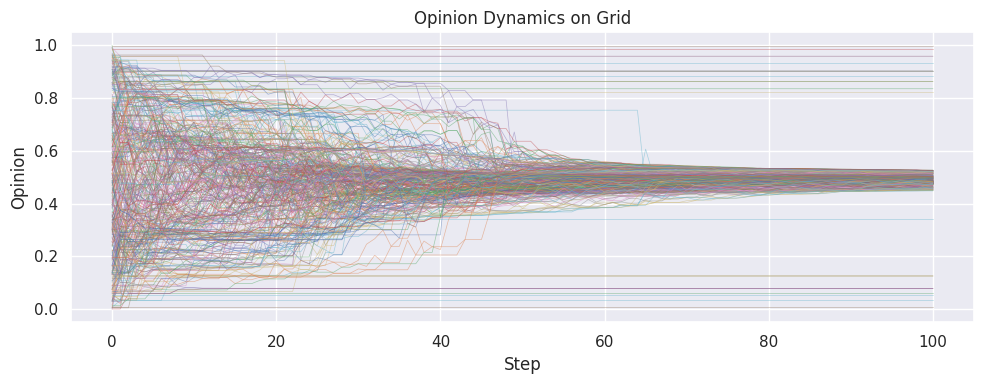

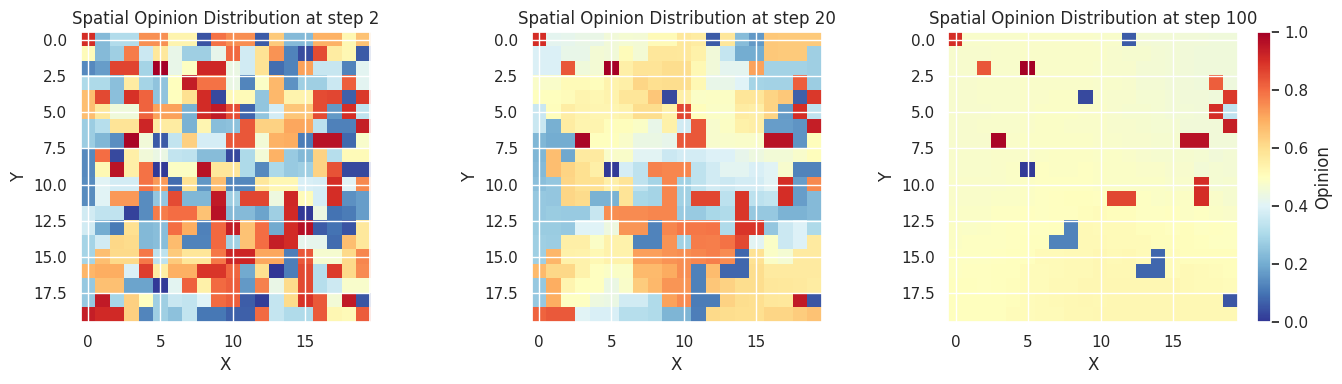

In [17]:
# Visualize spatial opinion distribution
agent_data = grid_model.datacollector.get_agent_vars_dataframe()
model_data = grid_model.datacollector.get_model_vars_dataframe()

VISUALIZATION_STEPS = 100
visualize_opinion_dynamics_multiple([agent_data], titles=["Opinion Dynamics on Grid"], visualization_steps=[VISUALIZATION_STEPS])
visualize_opinion_grid([model_data], GRID_ROUNDS)

### Using batch_run to run multiple configurations

In [18]:
# batch run with different thresholds
GRID_ROUNDS = 100

parameters = {
    "width": [20, 30, 40],
    "height": 10,
    "convergence": 0.5,
    "threshold": [0.25, 0.35],
    "is_square": True
}

grid_results = batch_run(BoundedConfidenceGridModel, parameters, max_steps=GRID_ROUNDS, number_processes=1, data_collection_period=1)

  0%|          | 0/6 [00:00<?, ?it/s]

Number of runs: 6


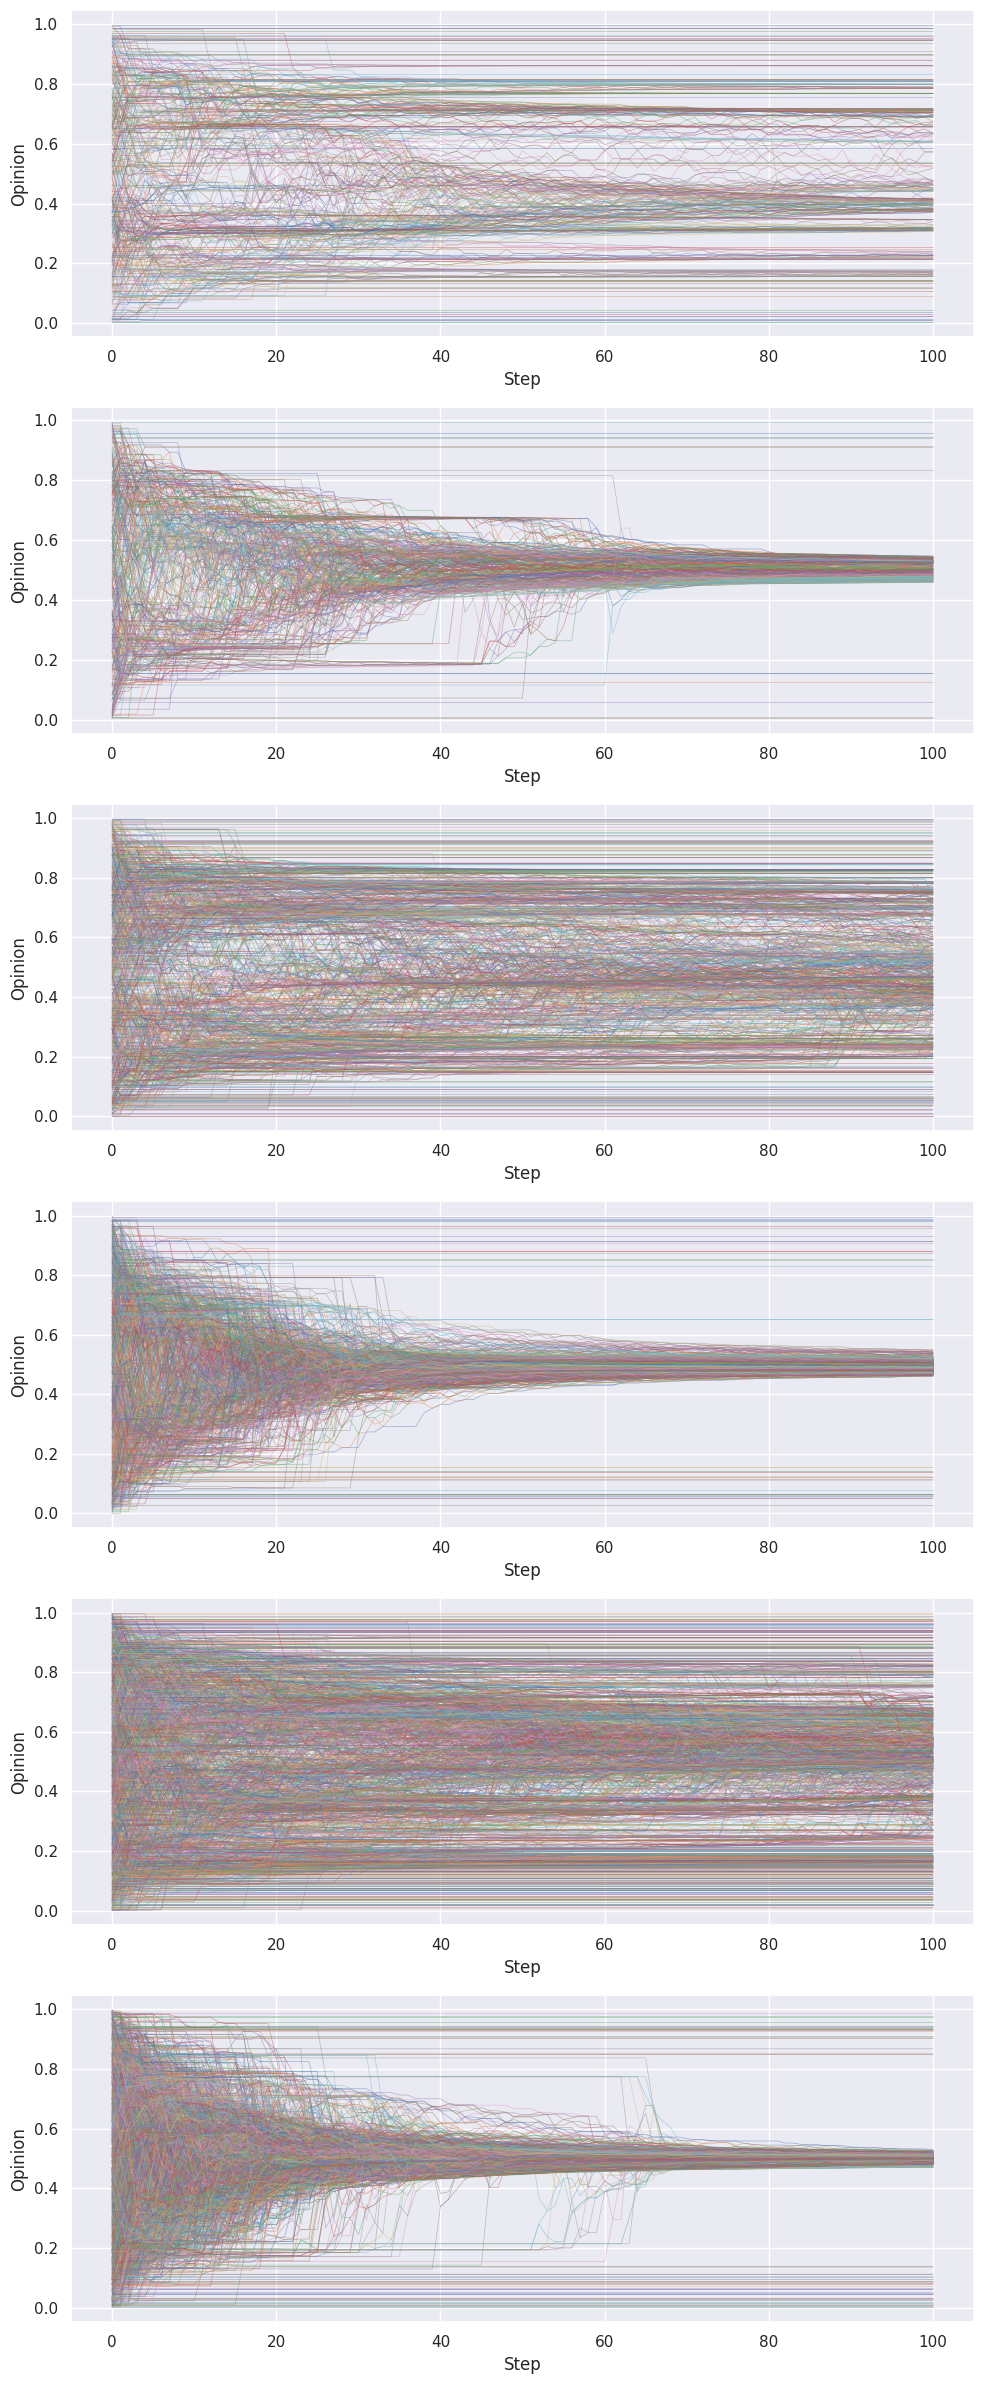

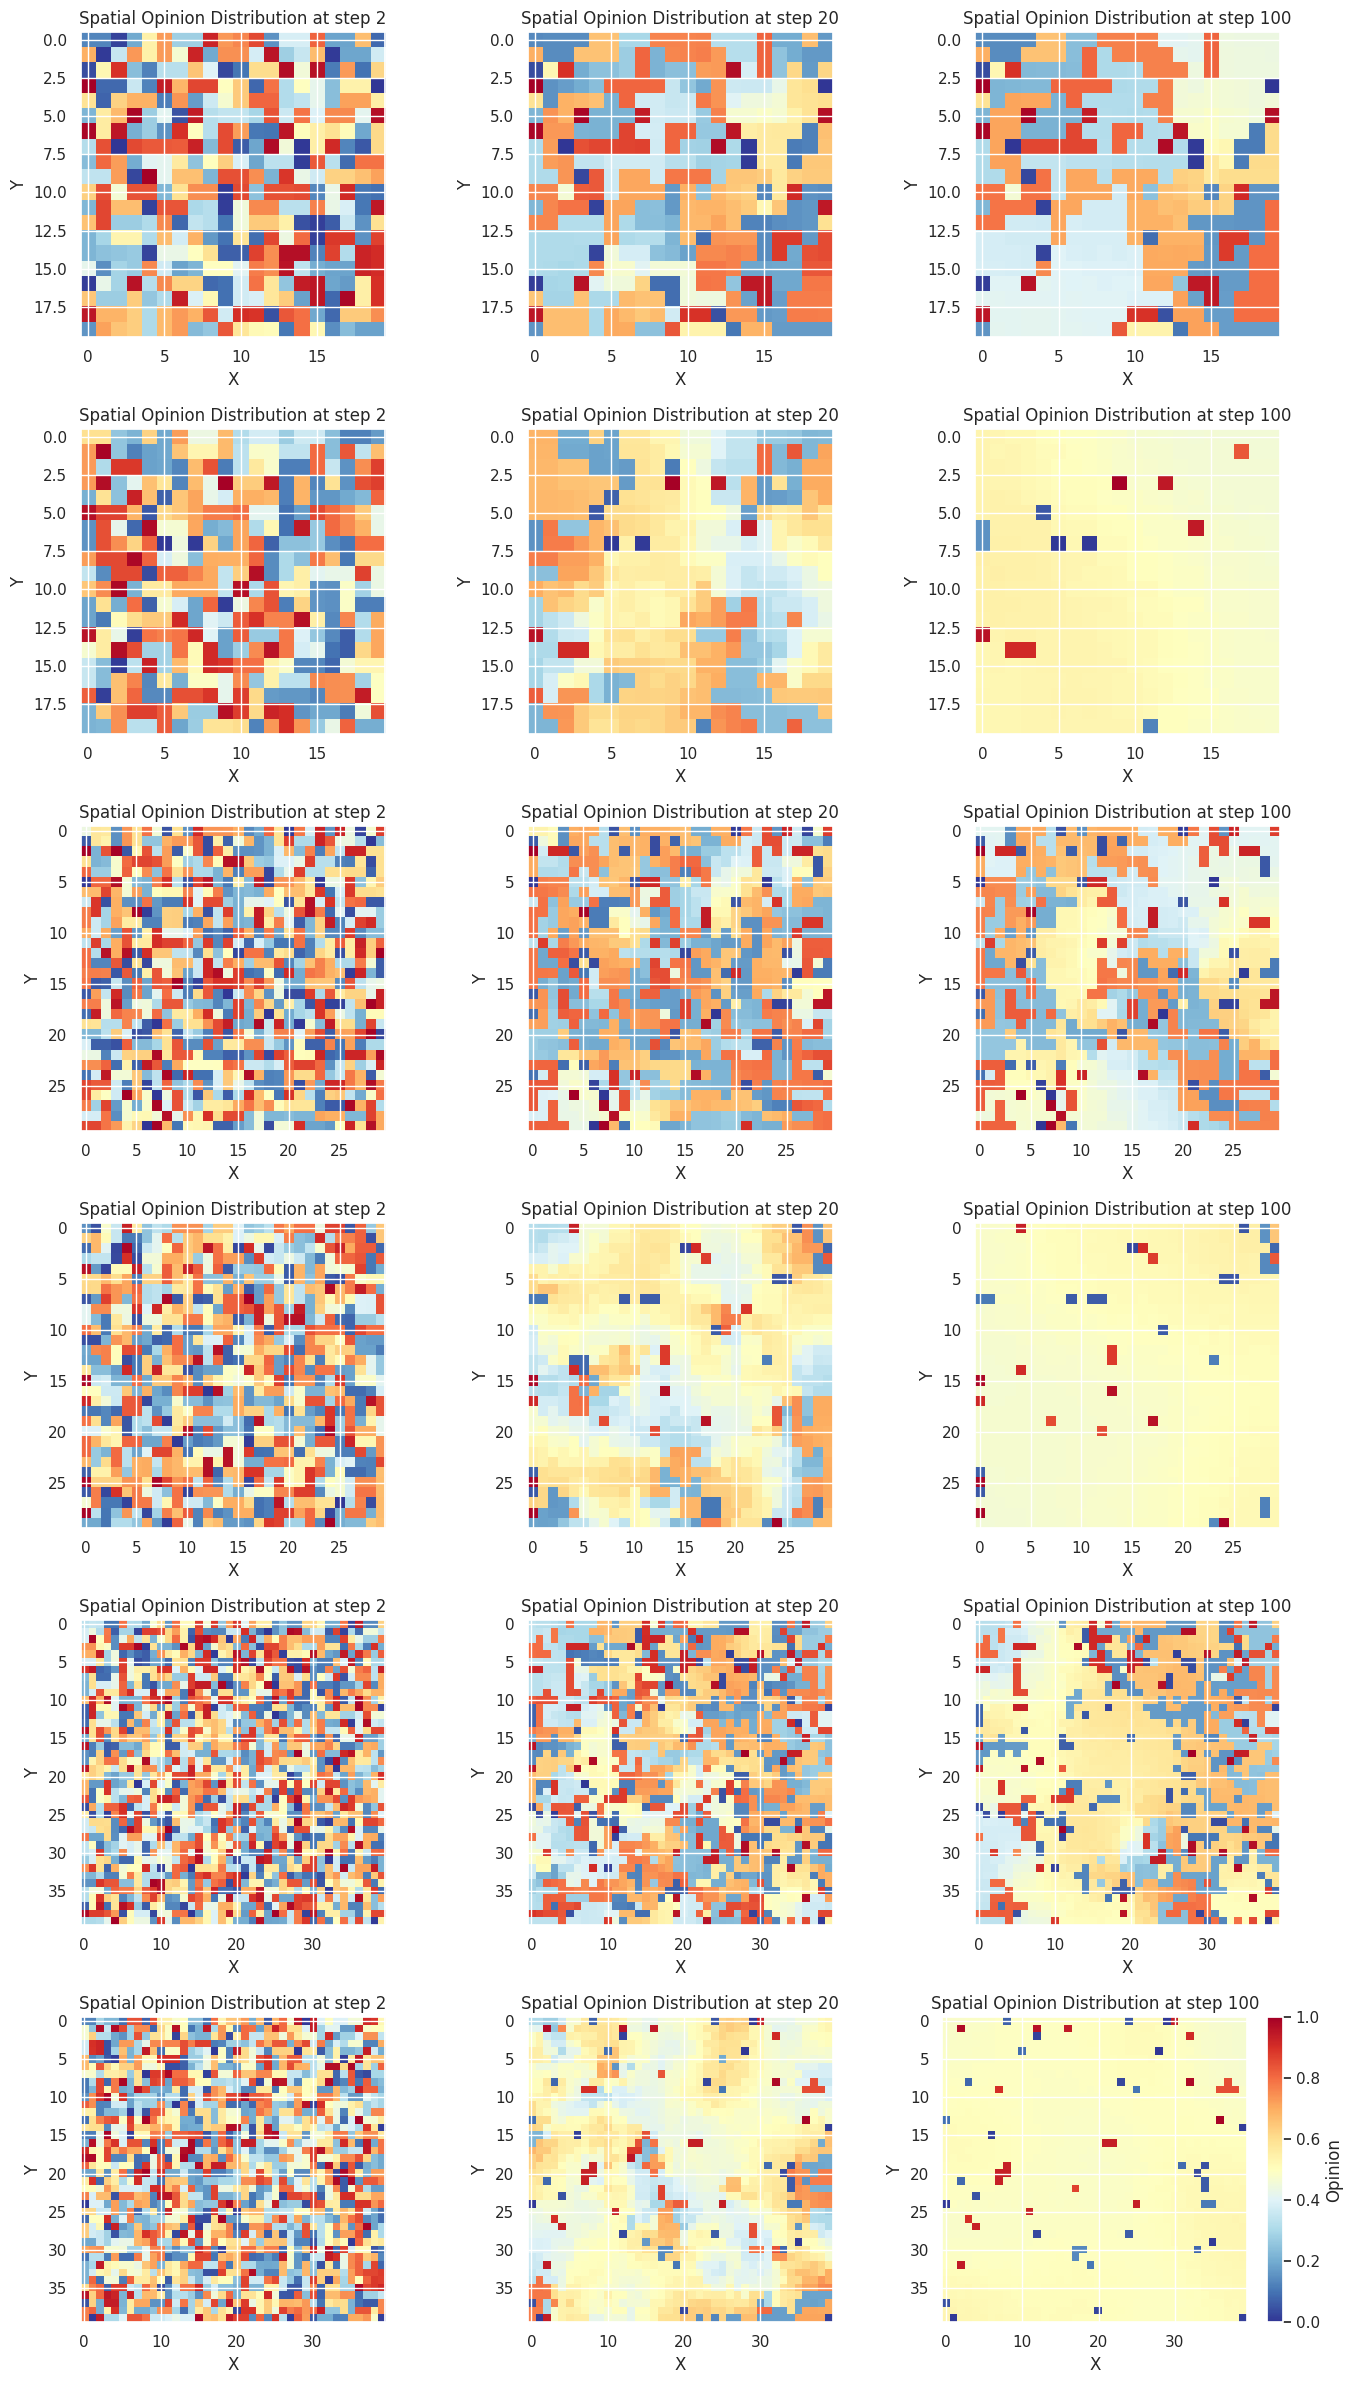

In [19]:
# Convert batch_run results to a DataFrame and group by RunId
grid_results_df = pd.DataFrame(grid_results)

# Create one dataframe per run for model and agent
run_agent_dataframes = []
run_model_dataframes = []
for run_id, group in grid_results_df.groupby("RunId"):
    agent_df = group.loc[:, ["Step", "AgentID", "Opinion", "threshold"]].reset_index(drop=True)
    model_df = group.loc[:, ["Step", "width", "height", "Opinion_grid", "Opinion_groups"]].reset_index(drop=True)
    model_df = model_df.drop_duplicates(subset="Step") #In case the datacollector is called twice in a round somehow
    run_agent_dataframes.append(agent_df)
    run_model_dataframes.append(model_df)

print("Number of runs:", len(run_agent_dataframes))

visualize_opinion_dynamics_multiple(run_agent_dataframes,
                                    titles=[f"" for _ in range(len(run_agent_dataframes))],
                                    visualization_steps=[ROUNDS]*len(run_agent_dataframes))

visualize_opinion_grid(run_model_dataframes,
                       rounds=GRID_ROUNDS)

Feel free to modify and play around with the parameters or model however you wish

## Part 3: Network-Based Model

In [20]:
import networkx as nx
from mesa.discrete_space import Network

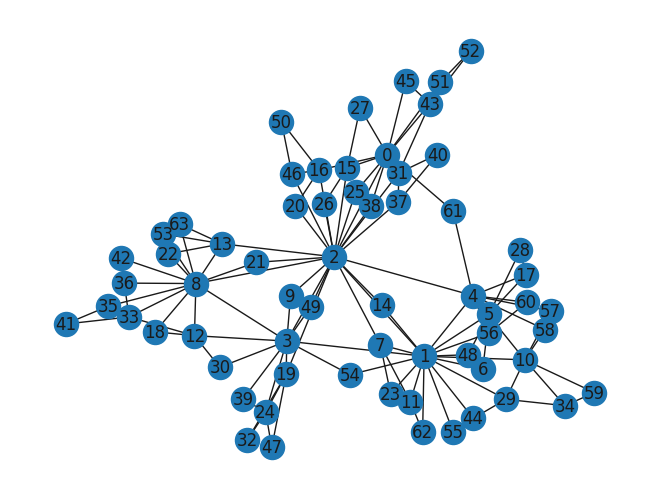

In [21]:
#For illustrative purposes let's generate a highly clustered network:
#The graph
G = nx.powerlaw_cluster_graph(n=64, m=2, p=0.99, seed=42) #n nodes, m new edges per node, p: Probability that the added edge will form a triangle with other edges - higher values result in a more clustered graph

node_layout = nx.spring_layout(G, seed=42) #Let's fix the positions of the nodes for printing so they don't change position every time printing the graph
nx.draw(G, node_layout, with_labels=True)

In [22]:
class BoundedConfidenceNetworkAgent(CellAgent): #Exactly the same as the BoundedConfidenceGridAgent - except self.node_id
    """An agent that lives on a network and interacts with neighbors only."""

    def __init__(self, model: Model, cell, opinion: float):
        """
        Create a new network-based bounded confidence agent.

        Args:
            model: The model instance
            cell: The network cell this agent occupies
            opinion: The random opinion value of the agent
        """
        super().__init__(model)
        self.cell = cell
        self.opinion = opinion
        self.node_id = cell.coordinate # Gives us the NetworkX id of the node the agent is occupying

    def step(self):
        """Interact with a random neighbor."""
        # Get list of neighbors
        other_agent = self.cell.neighborhood.select_random_agent()

        if other_agent: #Assuming it isn't a agent on a lonely island
            # Calculate opinion difference
            opinion_distance = abs(self.opinion - other_agent.opinion)

            # Adjust opinions if within threshold
            if opinion_distance < self.model.threshold:
                original_other_opinion = other_agent.opinion

                other_agent.opinion += self.model.convergence * (self.opinion - other_agent.opinion)
                self.opinion += self.model.convergence * (original_other_opinion - self.opinion)

In [23]:
class BoundedConfidenceNetworkModel(Model):
    """Model with Network: agents interact only with grid neighbors."""

    def __init__(self, graph, threshold: float, convergence: float, seed: int = None):
        """
        Initialize the grid-based bounded confidence model.

        Args:
            graph: NetworkX Graph
            threshold: Opinion difference threshold (0 to 1)
            convergence: Convergence parameter (0 to 0.5)
            seed: Random seed for reproducibility
        """
        super().__init__(rng=seed)
        self.threshold = threshold
        self.convergence = convergence

        # Create network space
        self.grid = Network(graph, capacity=1, random=self.random) #If we want to scale the graph up, we will extend the network and not add multiple agents to the same cell.
        num_nodes = graph.number_of_nodes()

        random_opinions = [self.random.random() for _ in range(num_nodes)] # A random opinion for every agent
        # Create one agent per node in the network
        # 1st parameter is the Model, 2nd parameter is the number of agents to create, afterwards the remaining parameters for BoundedConfidenceNetworkAgent are passed.
        BoundedConfidenceNetworkAgent.create_agents(self, num_nodes, self.grid.all_cells.cells, random_opinions)
        # Set up data collection
        self.datacollector = DataCollector(
            model_reporters={"Opinion_groups": get_opinion_groups},
            agent_reporters={"Opinion": "opinion", "Node_id": "node_id"}, #There are more performance-efficient ways, but let's add the node_id to the agent data for every round for simplicity
        )
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one step."""
        # Activate all agents in random order
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

agent_data (first lines):


Opinion  Node_id
Step AgentID                   
0.0  1        0.639427        0
     2        0.025011        1
     3        0.275029        2
     4        0.223211        3
     5        0.736471        4

model_data (first lines):


,Opinion_groups
0,4
1,5
2,5
3,4
4,4


Number of opinion groups at the beginning: 4
Number of opinion groups at the end: 1


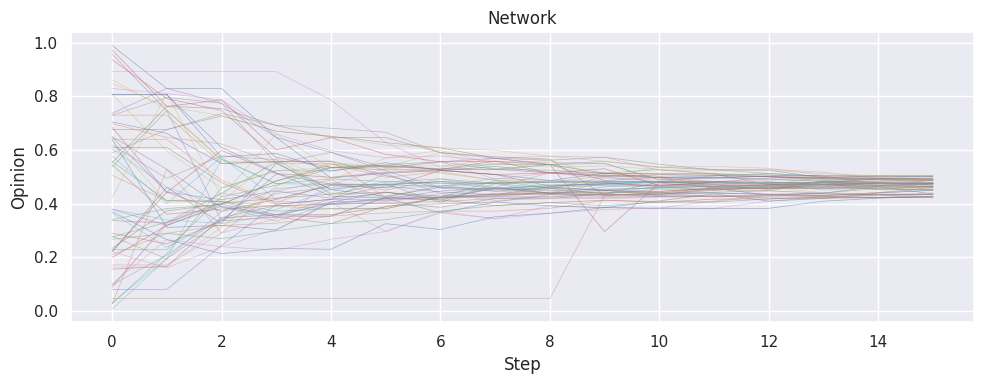

In [24]:
#Execute the model
GRID_ROUNDS = 100

network_mode = BoundedConfidenceNetworkModel(G, threshold=0.5, convergence=0.5, seed=42)
network_mode.run_for(GRID_ROUNDS)

agent_data = network_mode.datacollector.get_agent_vars_dataframe()
model_data = network_mode.datacollector.get_model_vars_dataframe()

#Give a preview of the Data:
print("agent_data (first lines):")
display(agent_data.head())
print("model_data (first lines):")
display(model_data.head())

print(f"Number of opinion groups at the beginning: {model_data["Opinion_groups"].iloc[0]}")
print(f"Number of opinion groups at the end: {model_data["Opinion_groups"].iloc[-1]}")

visualize_opinion_dynamics_multiple([agent_data], ["Network"], visualization_steps=[15])

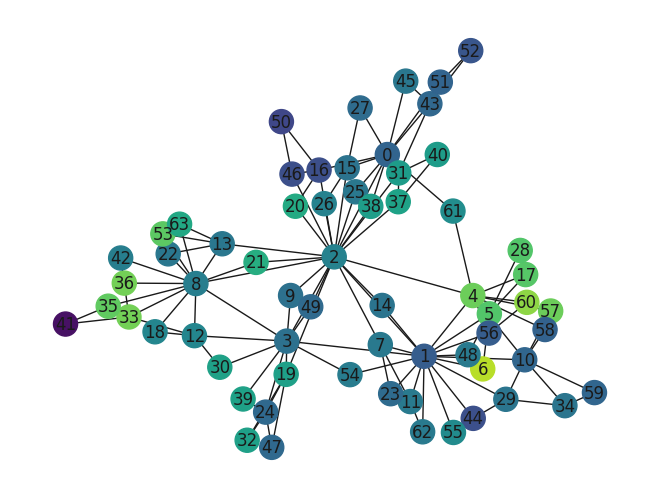

In [25]:
#Wow, the outlier on the bottom looks interesting. Let's dive into that at step 2:

def plot_network_at_specific_step(G, node_layout, agent_data, step):
  #Agent_data uses Multi-Indexes (which are horrible in my opinion), so let's extract what we need and get rid of the ("Step", "AgentID")-Multi-Index.
  #We need only data for the step we want to inspect; the AgentID is unimportant, so we can drop the old Index columns completely
  current_agent_data = agent_data[agent_data.index.get_level_values("Step") == step].reset_index(drop=True)
  node_opinions = current_agent_data.sort_values("Node_id")["Opinion"].tolist() #We can't assume the AgentID is connected to the NetworkX Node-ID, so let's convert the dataframe to a list of this sort: [opinion of node 0, opinion of node 1, ...]
  nx.draw(G, node_layout, node_color=node_opinions, cmap=plt.cm.viridis, vmin=0, vmax=1, with_labels=True) #Use some good looking colormap and fix the range from 0 to 1

plot_network_at_specific_step(G, node_layout, agent_data, step=2)

The outlier in opinion could be node 41 or node 6 I guess. A few steps later:

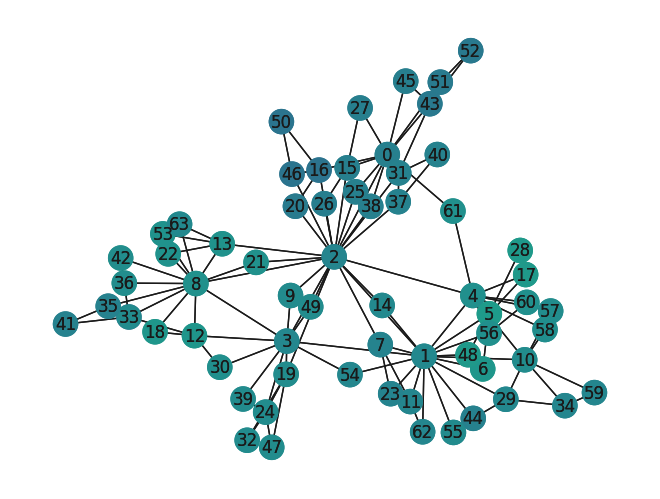

In [26]:
plot_network_at_specific_step(G, node_layout, agent_data, 9) #Oh, it was Node 41
plot_network_at_specific_step(G, node_layout, agent_data, 10) #Now they basically share the opinion